# 3b. Circulation analogues
The workflow for the circulation analogues is close to final, apart from links to software. It will be
added in the next deliverable D451.2.3.2. Some of the main steps will include:
- Identification of the domain to calculate analogues.
- Assessment on which circulation variable to use.
- Assessment of composites of analogues.
- Assessment of change in frequency of analogues.

In [68]:
# Imports
# import analogue_functions_C3S as my
import c3s_lib.analogue_functions_C3S as my

from c3s_lib import *
import requests
import urllib.parse
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import json
import geopandas as gpd
import rasterio
from rasterio import features
from shapely.geometry import shape, Polygon, mapping, MultiPolygon, GeometryCollection
from shapely.vectorized import contains # replace with below
from shapely import contains_xy
import xarray as xr
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.ops import unary_union
from datetime import datetime, timedelta
import pandas as pd
import contextily as ctx
import math
import regionmask
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import cmocean
import base64
from io import BytesIO
import contextily as ctx
from typing import Union, Literal
import os
import iris
import iris.coords as icoords
import cftime
import cf_units
from iris.cube import Cube
import iris.coord_systems as cs
import scipy.stats as stats
import calendar
import numpy.ma as ma
import cartopy.feature as cf


In [69]:
# Api key used for the DataClient, replace with your own API key from the C3S Climate Data Store
################# (User selection) ###################
your_api_key = '98256e82-4de4-4cc1-8087-faebb5c2e4ae'
######################################################

# Directory you wish to store output files in. using ../ specifies the parent directory
CURRENT_DIRECTORY = os.getcwd() # do not touch, __file__ specifies the current directory of the file

################# (User selection) ###################
your_save_directory = os.path.abspath(os.path.join(CURRENT_DIRECTORY, "../data"))   # change ../data to your desired directory
######################################################
os.makedirs(your_save_directory, exist_ok=True) # create directory if it does not exist

## 3.8 Make sure the software reads the four key variables from the event definition (probabilistic attribution):
- a. Event date, this is a single day. This should be the date where the hazard has the highest magnitude. This needs a manual decision based on the event definition of the probabilistic attribution, see figures from Step 2.13
- b. Hazard variable, either (hot or cold) temperature (t2m) (If possible needs to be changed to become Tmax, t2m or Tmin, depending on the probabilistic event definition.) or rainfall (tp)
- c. Probabilistic event region, used to define the hazard of the event, for plotting. This could be a shapefile or latitude/longitude boundaries of a box, saved in Step 2.3.
- d. Needs to be changed to reading in the event time series (daily series) from the probabilistic event definition.

### <font color='orange'>Please specify the following variables below to start the workflow</font>

In [70]:
# variable

# This is the beacon variable
parameter = "Tmean"
# This is the NetCDF variable
Haz = "t2m"

# date of the event for data client
event_date = datetime(2023, 3, 11)
# date of the event for iris functions
event_date_iris = [2023, 'Mar', 11] 

# period for analogue search
start_period = datetime(1950, 1, 1)
end_period = datetime(2025, 6, 30)
# periods in iris terms, just the years
Y1 = start_period.year
Y2 = end_period.year

# months used for analysis
months = my.analogue_months(event_date.month)
# number of analogues used for analysis
N = my.number_of_analogues(Y1, Y2, months)

In [71]:
# Domain

# variable geopandas region min lon, min lat, max lon, max lat
impact_domain = (-61, -36, -56, -32)
# iris [N, S, W, E]
impact_domain_iris = [impact_domain[3], impact_domain[1], impact_domain[2], impact_domain[0]]

# correlation domain world wide
correlation_domain = (-180, -90, 180, 90)
# iris
correlation_domain_iris = [correlation_domain[3], correlation_domain[1], correlation_domain[2], correlation_domain[0]]


# whole world is to large for our wsl
correlation_domain = (-65, -40, -52, -28)
# iris
correlation_domain_iris = [-28, -40, -52, -65]


# The selected study region for the Event definition
# shapefile location
studyregion_file = os.path.join(your_save_directory, "sf_studyregion.shp")
# import shapefile as gdf
studyregion = gpd.read_file(studyregion_file)
# extract the polygons
polygons = studyregion.geometry

In [72]:
# start_period = datetime(2023, 1, 1)
# end_period = datetime(2025, 11, 30)

# months = ["Jan", "Mar", "Jul", "Nov"]

# gr_daily = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter=parameter, bbox=impact_domain, time_range=(start_period, end_period), months=months, to_unit="c")

# gr_daily

Load in data

In [73]:
# # daily variable data
# gr_daily = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter=parameter, bbox=impact_domain, time_range=(start_period, end_period), months=months, to_unit="c")
# # daily z500 data
# z500_daily = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter="z500", bbox=correlation_domain, time_range=(start_period, end_period), months=months)
# # daily slp data
# slp_daily = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter="slp", bbox=correlation_domain, time_range=(start_period, end_period), months=months)

## Custom and Edited Functions by Maris

Move these to library later

In [74]:
# later move to library because this one does not again import data

def analogue_dates_v3(daily_cube, event_cube, N):
    '''
    daily_cube: cube with daily values
    event_cube: cube of just the event
    N: number of analogues
    '''
    def cube_date_to_string(cube_date : tuple) -> tuple:
        year,month,day,time = cube_date
        return str(year)+str(month).zfill(2)+str(day).zfill(2), time

    D = my.euclidean_distance(daily_cube, event_cube)
    date_list = []

    for i in np.arange(N):
        #print(i)
        I = np.sort(D)[i]
        for n, each in enumerate(D):
            if I == each:
                a1 = n
        date, time = cube_date_to_string(my.cube_date(daily_cube[a1,...]))
        date_list.append(date)
        date_list2 = my.date_list_checks(date_list, days_apart=5)
    return date_list2

In [75]:
# anaomaly period output for cubes

# cube with daily values, cube of just the event, variable used, date of the event, region, number of analogues
def anomaly_period_outputs_v2(daily_cube, event_cube, date, N):
    '''
    daily cube: iris cube with daily values
    event cube: iris cube with the event day
    date: date of the event [year, month abbrev, day]
    N: number of analogues
    '''

    # cube_daily = cube_daily[:, 0, :, :]  # shape = (time, lat, lon)
    # multiple days
    daily_cube = daily_cube - daily_cube.collapsed(['latitude', 'longitude'], iris.analysis.MEAN) # event for anavar to plot (fig a)

    # cube_event = cube_event[:, 0, :, :]  # shape = (time, lat, lon)
    # single day
    event_cube = event_cube - event_cube.collapsed(['latitude', 'longitude'], iris.analysis.MEAN) # event for anavar to plot (fig a)

    P1_dates = analogue_dates_v3(daily_cube, event_cube, N*5)[:N]

    if str(date[0])+str("{:02d}".format(list(calendar.month_abbr).index(date[1])))+str(date[2]) in P1_dates: # Remove the date being searched for
        P1_dates.remove(str(date[0])+str("{:02d}".format(list(calendar.month_abbr).index(date[1])))+str(date[2]))
        
    return P1_dates

In [76]:
# J: this is currently still being used because in one of the cells they need this for multiple different variables
# J: that are chosen depending of the analysis. so keep this until that issue is resolved

# ANALOGUE COMPOSITES
def analogues_composite_anomaly(dates, ana_var:str, region:list[float], Y1:int=1950, Y2:int=2025):
    '''
    dates: list of dates
    ana_var: variable to import
    region: selected region/area
    Y1: start year
    Y2: end year
    '''

    P1_msl = my.reanalysis_data_v2(ana_var, Y1, Y2, months) # Get ERA5 data, Y1 to Y2, for var and season chosen. Global.
    P1_field = my.extract_region(P1_msl, region) # Extract the analogues domain (R1) from global field    
    P1_spatialmean = P1_field.collapsed(['latitude', 'longitude'], iris.analysis.MEAN)   # Calculate spatial mean for each day
    P1_field = P1_field - P1_spatialmean # Remove spatial mean from each day
    P1_comp = my.composite_dates_anomaly(P1_field, dates) # composite analogues
    return P1_comp

In [77]:
def analogues_composite_anomaly_v2(cube, dates):
    '''
    cube: data cube
    dates: list of dates
    '''

    P1_spatialmean = cube.collapsed(['latitude', 'longitude'], iris.analysis.MEAN)   # Calculate spatial mean for each day
    P1_field = cube - P1_spatialmean # Remove spatial mean from each day
    P1_comp = my.composite_dates_anomaly(P1_field, dates) # composite analogues
    return P1_comp

In [78]:
# J: this is currently still being used because in one of the cells they need this for multiple different variables
# J: that are chosen depending of the analysis. so keep this until that issue is resolved

def analogues_composite(dates, ana_var, region, Y1:int=1950, Y2:int=2025):
    '''
    dates: list of dates
    ana_var: variable to import
    region: selected region/area
    Y1: start year
    Y2: end year
    '''
        
    P1_msl = my.reanalysis_data_v2(ana_var, Y1, Y2, months) # Get ERA5 data, Y1 to Y2, for var and season chosen. Global.
    P1_field = my.extract_region(P1_msl, region) # Extract the analogues domain (R1) from global field    
    P1_comp = my.composite_dates(P1_field, dates) # composite analogues
    return P1_comp

In [79]:
# adjust version of the function above to not reimport data

def analogues_composite_v2(dates, cube):
    P1_comp = my.composite_dates(cube, dates) # composite analogues
    return P1_comp

In [80]:
# adds background to plots
def background(ax):
    '''
    Adds background to given plot (ax)
    '''

    ax.coastlines(linewidth=0.4)
    #ax.add_feature(cf.BORDERS, lw = 1, alpha = 0.7, ls = "--", zorder = 99)
    gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.2, color='k',alpha=0.5,linestyle='--')
    gl.right_labels =gl.left_labels = gl.top_labels = gl.bottom_labels= False
    gl.xlabel_style = {'size': 5, 'color': 'gray'}
    gl.ylabel_style = {'size': 5, 'color': 'gray'}

In [81]:
# correlation value
def var_correlation(var_cube, correlation_cube):
    '''
    calculates the correlation between var_cube and correlation_cube
    '''

    z_data = correlation_cube 
    z_data = z_data - z_data.collapsed(['latitude', 'longitude'], iris.analysis.MEAN) # event for anavar to plot (fig a)
    a, b, c = np.shape(z_data.data)
    corr_field = np.empty((b,c))
    p_field = np.empty((b,c))
    for i in np.arange(b):
        print(i)
        for j in np.arange(c):
            x, y = stats.pearsonr(var_cube.data, z_data.data[:,i,j])
            corr_field[i,j] = x
            p_field[i,j] = y

    # p_field does not seem to be used
    return z_data, corr_field, p_field

In [ ]:
# Plot map of correlation
def plot_correlation_map(z_data, z500_correlation, slp_correlation, region, z500_domain, slp_domain,
                         draw_labels:bool=True, fig_size:tuple[float, float]=(10,10)):

    '''
    Plots the correlation figures for z500 and slp
    '''

    fig, ax = plt.subplots(2, 1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=fig_size)
    lats = z_data.coord('latitude').points
    lons = z_data.coord('longitude').points
    con_lev = np.linspace(-1, 1, 20)

    c1 = ax[0].contourf(lons, lats, z500_correlation, levels=con_lev, cmap='RdBu_r', transform=ccrs.PlateCarree())
    ax[0].add_feature(cfeature.COASTLINE)
    ax[0].coastlines(linewidth=0.4)
    ax[0].set_title('Corr Z500')
    ax[0].gridlines(draw_labels=draw_labels)
    my.plot_box(ax[0], region)
    my.plot_box(ax[0], z500_domain)

    c1 = ax[1].contourf(lons, lats, slp_correlation, levels=con_lev, cmap='RdBu_r', transform=ccrs.PlateCarree())
    ax[1].add_feature(cfeature.COASTLINE)
    ax[1].coastlines(linewidth=0.4)
    ax[1].set_title('Corr MSL')
    ax[1].gridlines(draw_labels=draw_labels)
    my.plot_box(ax[1], region)
    my.plot_box(ax[1], slp_domain)

    fig.subplots_adjust(right=0.8)
    cax = fig.add_axes([0.85, 0.3, 0.01, 0.4])
    cbar = fig.colorbar(c1, cax=cax, ticks=[-1, 0, 1])
    cbar.ax.set_yticklabels(['-1', '0', '1'])
    plt.tight_layout()

    return fig, ax

In [83]:
# guess bounds
def guess_bounds(cube, lat:str='latitude', lon:str='longitude'):
    if not cube.coord(lat).has_bounds():
        cube.coord(lat).guess_bounds()
    if not cube.coord(lon).has_bounds():
        cube.coord(lon).guess_bounds()

    return cube

In [84]:
def remove_bounds(cube, lat:str='latitude', lon:str='longitude'):
    if cube.coord(lat).has_bounds():
        cube.coord(lat).bounds = None
    if cube.coord(lon).has_bounds():
        cube.coord(lon).bounds = None

    return cube

In [85]:
def impact_index_v2(cube):
    '''
    Calculates the impact index over the cube
    II_domain: spatial extent of index
    '''
    grid_areas = iris.analysis.cartography.area_weights(cube)
    cube.data = ma.masked_invalid(cube.data)
    return cube.collapsed(('longitude','latitude'),iris.analysis.MEAN,weights=grid_areas).data

In [109]:
# Violin Plot (to visually check the result)
def violin_plot(II_event, II_z500, II_slp, fig_size:tuple[float, float]=(2.5, 2.5)):
    fig, axs = plt.subplots(nrows=1, ncols=1, figsize=fig_size)
    plots = axs.violinplot([II_z500, II_slp], showmeans=True, showextrema=False, widths = .8)
    plots["bodies"][1].set_facecolor('green')
    axs.axhline(II_event, color='r', label = 'Event')
    axs.set_xticks([1,2], labels=['Z500', 'SLP'])
    axs.tick_params(axis='x', length=0)
    if Haz == 't2m': axs.set_ylabel('Temperature (K)')
    if Haz == 'tp': axs.set_ylabel('Daily Rainfall (mm)')
    t, p = stats.ttest_ind(II_z500, II_slp, equal_var=False, alternative='two-sided')
    if p < 0.05:
        axs.set_title(('%.2f'%t), pad=-20, loc='left', fontweight="bold")
    else:
        axs.set_title(('%.2f'%t), pad=-20, loc='left')

    return fig, axs

In [116]:
# Shown for larger range of analogue proportions

def analogue_proportions(II_event, II_z500, II_slp, N, fig_size:tuple[float,float]=(2.5, 2.5), xlim:float=10):

    meanT = []
    for i in np.arange(len(II_z500)):
        meanT.append(np.mean(II_z500[:i]))

    fig, axs = plt.subplots(nrows=1, ncols=1, figsize=fig_size)
    axs.plot(meanT, 'b', label = 'Z500')

    meanT = []
    for i in np.arange(len(II_slp)):
        meanT.append(np.mean(II_slp[:i]))

    axs.plot(meanT, 'g', label = 'SLP')
    axs.set_xlim([xlim, N])
    axs.axhline(II_event, color='r', label = 'Event')
    axs.legend() 
    axs.set_ylabel('Hazard')
    axs.set_xlabel('# of analogues')

    return fig, axs

In [86]:
# J: this function is never used

def plot_specified_date(axs, fig, ax, date, title, ana_var, haz_var, R1): 
    circ = my.extract_region(my.reanalysis_data_single_date(ana_var, date), R1)
    #E = E - E.collapsed(['latitude', 'longitude'], iris.analysis.MEAN)
    haz = my.extract_region(my.reanalysis_data_single_date(haz_var, date), R1)
    lats=haz.coord('latitude').points
    lons=haz.coord('longitude').points
    if haz_var == 'tp':
        c = ax.contourf(lons, lats, haz.data, levels=np.linspace(1, 80, 9), cmap = plt.cm.get_cmap('Blues'), transform=ccrs.PlateCarree(), extend='max')
        fig.subplots_adjust(right=0.8)
        cbar_ax = fig.add_axes([0.85, 0.3, 0.02, 0.4])
        fig.colorbar(c, cax=cbar_ax, ticks=np.arange(0, 100, 10))
        cbar_ax.set_ylabel('Total Precipitation (mm)', labelpad=10, rotation=270, fontsize=12)
        cbar_ax.set_yticklabels(['0', '', '20','','40','','60','','80',''])
    elif haz_var == 't2m':
        c = ax.contourf(lons, lats, haz.data-273.15, levels=np.linspace(np.min(haz.data-273.15), np.max(haz.data-273.15), 9), cmap = plt.cm.get_cmap('RdBu_r'), transform=ccrs.PlateCarree(), extend='max')
        fig.subplots_adjust(right=0.8)
        cbar_ax = fig.add_axes([0.85, 0.3, 0.02, 0.4])
        fig.colorbar(c, cax=cbar_ax, ticks=np.arange(np.min(haz.data-273.15), np.max(haz.data-273.15), 5))
        cbar_ax.set_ylabel('t2m', labelpad=10, rotation=270, fontsize=12)
        #cbar_ax.set_yticklabels(['0', '', '20','','40','','60','','80',''])
    lats=circ.coord('latitude').points
    lons=circ.coord('longitude').points
    c2 = axs.contour(lons, lats, circ.data/100, colors='k', transform=ccrs.PlateCarree(), extend='both')
    axs.clabel(c2, inline=1, fontsize=12)
    axs.add_feature(cf.BORDERS)
    axs.add_feature(cf.COASTLINE)
    axs.set_title(title, loc='left')

## 3.9 Identify domains to calculate analogues over:
- a. Action: run script C3S01_analogues_Domain.ipynb
    - i. This step requires input of the initial variables (Step 3.8), and assessment of the analogue domains by re-running the final cell.
    - ii. Software creates plots with correlations to decide on the analogues domain Supp.Fig.1 (see Figures description section)
- b. Action: determine the domains, by manually assessing Supp.Fig.1
    - i. Use the 3-month window around the event unless there is a clear reason to deviate
    - ii. Software calculates the correlation between the event time series and Z500 as well as msl
    - iii. Software produces Z500 and msl figures showing correlation with event time series as well as the event domain
    - iv. Software produces Z500 and msl figures showing correlation with event time series as well as a chosen domain, indicating the ratio blue/red; Supp.Fig.1 (see Figures description section)
        - 9.b.iv.1. Choose a domain (box) which covers the region of greatest correlation in absolute terms (furthest from zero). See Figures Description for an example. The domain is likely to differ for each variable (Z500 and msl).
        - 9.b.iv.2. Re-run until the cell of ratios of red/blue to test different options until the ratios are between 0.2 and 0.3
        - 9.b.iv.2.1. Some events may need expert judgement and a different ratio. Especially precipitation events need some more thorough testing/judgement.
- c. Action: check the final text output, which shows the details of the event and provides inputs for next stages (analogues domains)

## Turn the gdfs into iris cubes

In [87]:
# delete after 3D beacon

def gdf_to_cube(gdf, var_name='t2m'):
    gdf['valid_time'] = pd.to_datetime(gdf['valid_time'])
    gdf = gdf.sort_values(['valid_time', 'latitude', 'longitude'])

    lats = np.sort(gdf['latitude'].unique())
    lons = np.sort(gdf['longitude'].unique())
    times = pd.to_datetime(gdf['valid_time'].unique())

    time_unit = cf_units.Unit('days since 1970-01-01', calendar='gregorian')
    time_points = time_unit.date2num(times.to_pydatetime())

    lat_coord = icoords.DimCoord(lats, standard_name='latitude', units='degrees')
    lon_coord = icoords.DimCoord(lons, standard_name='longitude', units='degrees')
    time_coord = icoords.DimCoord(time_points, standard_name='time', units=time_unit)

    data = (
        gdf.pivot_table(index='valid_time', columns=['latitude', 'longitude'], values=var_name)
        .to_numpy()
        .reshape(len(times), len(lats), len(lons))
    )

    cube = Cube(
        data,
        dim_coords_and_dims=[(time_coord, 0), (lat_coord, 1), (lon_coord, 2)],
        standard_name="air_temperature",
        var_name=var_name,
        units="degC",
    )

    return cube


In [88]:
# # delete after 3D beacon

# gr_daily_cube = gdf_to_cube(gr_daily, var_name='t2m')

# gr_daily_cube

In [89]:
# delete after 3D beacon

def gdf_to_cube_z500(gdf, var_name='z'):
    """
    Convert a gridded GeoDataFrame (with pressure levels) to an Iris Cube.
    Expected columns: valid_time, pressure_level, latitude, longitude, <var_name>
    """
    # Ensure datetime
    gdf['valid_time'] = pd.to_datetime(gdf['valid_time'])

    # Sort for consistency
    gdf = gdf.sort_values(['valid_time', 'pressure_level', 'latitude', 'longitude'])

    # Unique coordinates
    times = pd.to_datetime(gdf['valid_time'].unique())
    levs = np.sort(gdf['pressure_level'].unique())
    lats = np.sort(gdf['latitude'].unique())
    lons = np.sort(gdf['longitude'].unique())

    # Time coordinate (convert to numeric)
    time_unit = cf_units.Unit('days since 1970-01-01', calendar='gregorian')
    time_points = time_unit.date2num(times.to_pydatetime())

    # Create DimCoords
    time_coord = icoords.DimCoord(time_points, standard_name='time', units=time_unit)
    lev_coord = icoords.DimCoord(levs, standard_name='air_pressure', units='hPa')
    lat_coord = icoords.DimCoord(lats, standard_name='latitude', units='degrees')
    lon_coord = icoords.DimCoord(lons, standard_name='longitude', units='degrees')

    # Pivot data into 4D array: (time, level, lat, lon)
    # Step 1: pivot to wide table per time-level
    data_4d = np.empty((len(times), len(levs), len(lats), len(lons)))

    for t_i, t in enumerate(times):
        for l_i, lev in enumerate(levs):
            sub = gdf[(gdf['valid_time'] == t) & (gdf['pressure_level'] == lev)]
            pivot = sub.pivot_table(index='latitude', columns='longitude', values=var_name)
            data_4d[t_i, l_i, :, :] = pivot.to_numpy()

    # Create cube
    cube = Cube(
        data_4d,
        dim_coords_and_dims=[
            (time_coord, 0),
            (lev_coord, 1),
            (lat_coord, 2),
            (lon_coord, 3),
        ],
        standard_name='geopotential_height',
        var_name=var_name,
        units='m',  # typically geopotential height in meters
    )

    return cube


In [90]:
# delete after 3D beacon

def gdf_to_cube_z500(gdf, var_name='z'):
    """
    Convert a gridded GeoDataFrame to a 3D Iris Cube: (time, lat, lon).
    Assumes exactly one pressure level in the input (e.g., z500).
    """

    # Ensure datetime
    gdf['valid_time'] = pd.to_datetime(gdf['valid_time'])

    # Sort rows for stable ordering
    gdf = gdf.sort_values(['valid_time', 'latitude', 'longitude'])

    # Extract unique coordinates
    times = np.array(gdf['valid_time'].unique())
    lats  = np.sort(gdf['latitude'].unique())
    lons  = np.sort(gdf['longitude'].unique())

    # Pressure level (single value)
    pressure_level = float(gdf['pressure_level'].iloc[0])

    # --- Time coordinate ---
    time_unit = cf_units.Unit('days since 1970-01-01', calendar='gregorian')
    time_points = time_unit.date2num(pd.to_datetime(times).to_pydatetime())
    time_coord = icoords.DimCoord(time_points, standard_name='time', units=time_unit)

    # --- Lat/Lon coordinates ---
    lat_coord = icoords.DimCoord(lats, standard_name='latitude', units='degrees')
    lon_coord = icoords.DimCoord(lons, standard_name='longitude', units='degrees')

    # Prepare data array
    data = np.empty((len(times), len(lats), len(lons)))

    # Fill per time step
    for ti, t in enumerate(times):
        sub = gdf[gdf['valid_time'] == t]
        pivot = sub.pivot_table(index='latitude', columns='longitude', values=var_name)
        data[ti, :, :] = pivot.to_numpy()

    # --- Create Cube ---
    cube = Cube(
        data,
        dim_coords_and_dims=[
            (time_coord, 0),
            (lat_coord, 1),
            (lon_coord, 2),
        ],
        standard_name='geopotential_height',
        var_name=var_name,
        units='m',
    )

    # Store pressure level as metadata
    cube.attributes['pressure_level'] = pressure_level

    return cube


In [91]:
# # delete after 3D beacon

# z500_daily_cube = gdf_to_cube_z500(z500_daily, var_name='z')

# z500_daily_cube

In [92]:
# delete after 3D beacon

def gdf_to_cube_slp(gdf, var_name='msl'):
    gdf['valid_time'] = pd.to_datetime(gdf['valid_time'])
    gdf = gdf.sort_values(['valid_time', 'latitude', 'longitude'])

    # Unique coordinates
    times = pd.to_datetime(gdf['valid_time'].unique())
    lats = np.sort(gdf['latitude'].unique())
    lons = np.sort(gdf['longitude'].unique())

    # Time coordinate: numeric values using cf_units
    time_unit = cf_units.Unit('days since 1970-01-01', calendar='gregorian')
    time_points = time_unit.date2num(times.to_pydatetime())

    # Latitude / longitude coordinates
    lat_coord = icoords.DimCoord(lats, standard_name='latitude', units='degrees')
    lon_coord = icoords.DimCoord(lons, standard_name='longitude', units='degrees')
    time_coord = icoords.DimCoord(time_points, standard_name='time', units=time_unit)


    # # Create 3D data array (time, lat, lon)
    # data = np.full((len(times), len(lats), len(lons)), np.nan)

    # for i, t in enumerate(times):
    #     df_t = gdf[gdf['valid_time'] == t]
    #     pivot = df_t.pivot_table(index='latitude', columns='longitude', values=var_name)
    #     # Ensure order matches coordinates
    #     pivot = pivot.reindex(index=lats, columns=lons)
    #     data[i, :, :] = pivot.values

    data = (
        gdf.pivot_table(index='valid_time', columns=['latitude', 'longitude'], values=var_name)
        .to_numpy()
        .reshape(len(times), len(lats), len(lons))
    )


    # Build cube
    cube = Cube(
        data,
        dim_coords_and_dims=[(time_coord, 0), (lat_coord, 1), (lon_coord, 2)],
        standard_name='air_pressure_at_sea_level',
        var_name=var_name,
        long_name='Mean Sea Level Pressure',
        units='Pa'
    )

    return cube


In [93]:
# # delete after 3D beacon

# slp_daily_cube = gdf_to_cube_slp(slp_daily)

# slp_daily_cube

## Run the domains analogue

In [94]:
# load daily date for time range.
# NO user input needed

# event var
gr_daily_cube = my.reanalysis_data_v2(Haz, Y1, Y2, months)
# z500
z500_daily_cube = my.reanalysis_data_v2("z500", Y1, Y2, months)
# slp
slp_daily_cube = my.reanalysis_data_v2("msl", Y1, Y2, months)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [95]:
# Select region for paramater / Haz / variable
# NO user input needed

wgs84 = cs.GeogCS(6378137.0, 6356752.3142) # 'EPSG:4326' equivelant the shapefile is saved to

# setting the coordinate system is necessary for masking with a shapefiles
gr_daily_cube.coord('latitude').coord_system = wgs84
gr_daily_cube.coord('longitude').coord_system = wgs84

# extract the region using the bounding box, only needed for files, can be removed when using beacon
gr_daily_cube_reg = my.extract_region(gr_daily_cube, impact_domain_iris)

# mask the chosen variable data using the shapefile created in the event definition
# test if this is correctly done or if we can also have multiple polygons
gr_daily_cube_shape = my.extract_region_shape(gr_daily_cube, polygons[0])

# regions need to be extracting when importing data from files, can be removed when using beacon
z500_daily_cube_reg = my.extract_region(z500_daily_cube, correlation_domain_iris)
slp_daily_cube_reg = my.extract_region(slp_daily_cube, correlation_domain_iris)


In [96]:
# guess bounds if not present
lat = 'latitude'
lon = 'longitude'

# NO user input need
gr_daily_cube_reg = guess_bounds(gr_daily_cube_reg)

z500_daily_cube_reg = guess_bounds(z500_daily_cube_reg)

slp_daily_cube_reg = guess_bounds(slp_daily_cube_reg)

In [97]:
# calculate the correlation between variable and z550, slp
# NO user input need

weights = iris.analysis.cartography.area_weights(gr_daily_cube_reg)
coords = ('longitude', 'latitude')
t_ts, _ = gr_daily_cube_reg.collapsed(coords, iris.analysis.MEAN, weights=weights, returned=True)

## Correlation Z500, parameter_field does not seem to be used
z_data, correlation_field_z500, parameter_field_z500 = var_correlation(t_ts, z500_daily_cube_reg)

## Correlation SLP
z_data, correlation_field_slp, parameter_field_slp = var_correlation(t_ts, slp_daily_cube_reg)

# z_data is used for both plots, seems to be getting calculated for both z500 and slp but overwritten with the slp result

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spherical earth from ellipsoid.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


In [98]:
# specifiy z500 and slp domain based on plot
# z500
z500_domain = (-70, -30, -55, -20)
z500_domain_iris = [-20, -55, -30, -70] 
# slp/msl
slp_domain = (-80, -35, -55, -25)
slp_domain_iris = [-25, -55, -35, -80] 

# testing
z500_domain = correlation_domain_iris
slp_domain = correlation_domain_iris

/tmp/ipykernel_884240/4169859993.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


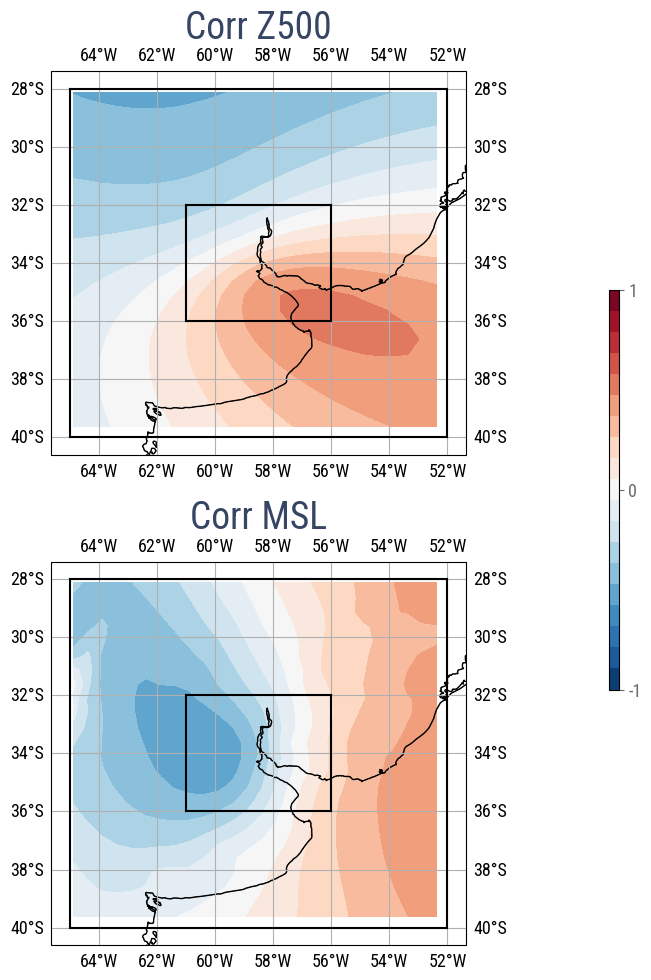

In [99]:
fig, ax = plot_correlation_map(z_data, correlation_field_z500, correlation_field_slp, impact_domain_iris, z500_domain, slp_domain)

In [100]:
## To ensure the domain adequately captures the sclae required for it to be the large-scale dynamics we are assessing, not local level patterns, this section checks the ratio of 'red' to 'blue'. 
# There may be cases where blue dominated the correlation (i.e. negative correlation, which would be expected for rainfall where low-pressure is likely to dominate high rainfall)
# Thus teh final line would need changing:
# print('SLP Blue: ',blue, ' Red: ', red, ' Ratio: ', red/(red+blue)) 
# Ratio required - around 25% (.2 to .3)

## This bit could be used to automate the region: find point of highest corr and then find box that gives 20:80 red:blue
X = z_data[0,:,:] 
X.data = correlation_field_z500
Y = my.extract_region(X, z500_domain)

a,b = np.shape(Y.data)
blue = 0
red = 0
for i in np.arange(a):
 for j in np.arange(b):
  if Y.data[i,j] < 0:
   blue +=1
  else:
   red +=1

print('Z500 Blue: ',blue, ' Red: ', red, ' Ratio: ', blue/(red+blue)) # want val ~.2

X = z_data[0,:,:] 
X.data = correlation_field_slp
Y = my.extract_region(X, slp_domain)

a,b = np.shape(Y.data)
blue = 0
red = 0
for i in np.arange(a):
 for j in np.arange(b):
  if Y.data[i,j] < 0:
   blue +=1
  else:
   red +=1

print('SLP Blue: ',blue, ' Red: ', red, ' Ratio: ', blue/(red+blue)) # want val .2-.3

Z500 Blue:  305  Red:  293  Ratio:  0.5100334448160535
SLP Blue:  335  Red:  263  Ratio:  0.560200668896321


In [101]:
# Summary print out
print('Summary: identify analogues domain')
print('Event definition:')
print('     Date: ', event_date_iris)
print('     Hazard: ', parameter)
print('     Impact domain: ', impact_domain_iris)
# print('     Months assessed: ', months)
print('     Months assessed: ', ['None'])
print('RESULT:')
print('    Z500 domain:', z500_domain_iris)
print('    MSL domain:', slp_domain_iris)


Summary: identify analogues domain
Event definition:
     Date:  [2023, 'Mar', 11]
     Hazard:  Tmean
     Impact domain:  [-32, -36, -56, -61]
     Months assessed:  ['None']
RESULT:
    Z500 domain: [-20, -55, -30, -70]
    MSL domain: [-25, -55, -35, -80]


## 3.10 Assess which circulation variable to use – msl or Z500:
- a. Action: run script C3S02_analogues_VariableChoice.ipynb
    - i. Requires input of the initial variables (determined in Step 3.9c)
    - ii. Software creates lists of analogues and calculates the impact index, produces violin plots and number of analogues plot (Supp.Fig.2 and 3; see Figures description section)
- b. Action: check the final text output, which shows the details of the event and provides input for the next Step (analogue variable Z500 or msl
    - i. Note: the output provides information assuming both a hot or heavy precipitation (high values) and cold (low values) extreme, ensure the correct result is chosen for next step.

In [102]:
# extact region again based on selected domains

# might not need to reimport new data
# z500_daily_cube = my.reanalysis_data_v2("z500", Y1, Y2, months)
z500_daily_cube_reg = my.extract_region(z500_daily_cube, z500_domain_iris)

# slp_daily_cube = my.reanalysis_data_v2("msl", Y1, Y2, months)
slp_daily_cube_reg = my.extract_region(slp_daily_cube, slp_domain_iris)

In [103]:
# select for the event date, using the region selected daily cubes

event_Haz_reg = my.extract_date(gr_daily_cube_reg, event_date_iris[0], event_date_iris[1], event_date_iris[2])
z500_event_cube = my.extract_date(z500_daily_cube_reg, event_date_iris[0], event_date_iris[1], event_date_iris[2])
slp_event_cube = my.extract_date(slp_daily_cube_reg, event_date_iris[0], event_date_iris[1], event_date_iris[2])

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [104]:
### Lists of analogues for all combination
dates_z500 = anomaly_period_outputs_v2(z500_daily_cube_reg, z500_event_cube, event_date_iris, N)
dates_slp = anomaly_period_outputs_v2(slp_daily_cube_reg, slp_event_cube, event_date_iris, N)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial c

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spherical earth from ellipsoid.
  warnings.warn(


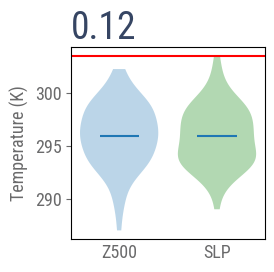

In [113]:
# violin plot

II_event = impact_index_v2(event_Haz_reg)

II_z500 = []
daily_analogues = my.analogues_list(gr_daily_cube_reg, dates_z500)  
for each in daily_analogues:
    II_z500.append(impact_index_v2(each))

II_slp = []
daily_analogues = my.analogues_list(gr_daily_cube_reg, dates_slp)  
for each in daily_analogues:
    II_slp.append(impact_index_v2(each))

fig, axs = violin_plot(II_event, II_z500, II_slp)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


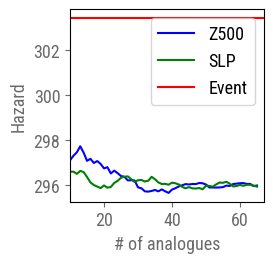

In [118]:
fig, axs = analogue_proportions(II_event, II_z500, II_slp, N)

In [119]:
# Summary print out
print('Summary: identify circulation variable')
print('Event definition:')
print('     Date: ', event_date_iris)
print('     Hazard: ', Haz)
print('     Impact domain: ', impact_domain_iris)
print('     Months assessed: ', months)
print('     Number of analogues: ', N)
print('     Z500 domain:', z500_domain_iris)
print('     MSL domain:', slp_domain_iris)
print('Results if heat / rain:')

u, p = stats.ttest_ind(II_z500, II_slp, equal_var=False, alternative='two-sided')
if np.mean(II_z500) > np.mean(II_slp):
    print('Recommend using Z500')
else:
    print('Recommend using SLP')

print('Results if cold extreme:')

u, p = stats.ttest_ind(II_z500, II_slp, equal_var=False, alternative='two-sided')
if np.mean(II_z500) > np.mean(II_slp):
    print('Recommend using SLP')
else:
    print('Recommend using Z500')


if p < 0.05:
    print('  Statistically significant difference')
else:
    print('  Difference is not statistically significant')


Summary: identify circulation variable
Event definition:
     Date:  [2023, 'Mar', 11]
     Hazard:  t2m
     Impact domain:  [-32, -36, -56, -61]
     Months assessed:  ['Feb', 'Mar', 'Apr']
     Number of analogues:  67
     Z500 domain: [-20, -55, -30, -70]
     MSL domain: [-25, -55, -35, -80]
Results if heat / rain:
Recommend using Z500
Results if cold extreme:
Recommend using SLP
  Difference is not statistically significant


## 3.11 Assess composites of analogues:
- a. Action: run script C3S03_analogues_Composites.ipynb
    - i. Requires input of initial variables
        - 11.a.i.1. analogue variable (from Step 3.10b)
        - 11.a.i.2. analogue domain (from Step 3.9c, choose the domain corresponding to the analogue variable)
    - ii. Software produces composite figures (Fig.Supp.4 & Fig.1 (See Figures description section))
- b. Software uses 1% of analogues
- c. Software uses time slices of 1950-1980 and 1994-2024 (potentially change 2nd time slice by a year after 2025)
- d. Software calculates analogue composites
- e. analogue composites
    - i. Action: manually ensure that the analogue composites shows analogues which closely resemble the observed event.
        - 11.e.i.1. Do subplots b and c look similar to a? Do they show the same large-scale circulation patterns?
        - 11.e.i.2. If not, re-check input variables, and Steps 3.9 and 3.10,
        - 11.e.i.3. Else consider if the event is too dynamically unusual to use analogues.
    - ii. In case the circulation situation is found to be too unique for analogues to describe past and present composites, stop here and describe in the Scientific Report Sect. XX that analogues could not be used since the circulation is too unique.
- f. Software plots z500, msl, tp, t2m of event, past composite, present day composite and difference including significance.
    - i. Action: check the final text output to ensure correct inputs
    - ii. Action: interpretation of results:
        - 11.f.ii.1. Focus on the chosen circulation variable and the event variable, the other figures may give some guidance but do not need interpretation
        - 11.f.ii.2. Notable differences, such as statistically significant differences between past and present in regions of high or low pressure (likely to influence the meteorological hazard) should be noted in the report text (next Step).
        - 11.f.ii.3. Note – the fields are not anomaly fields, therefore the changes include both thermodynamical and dynamical changes. There is likely to be an increase in temperature through time – at least partly explainable by increasing global temperatures.
    - iii. Copy the final Figure to the scientific report, to become the first analogues figure
- g. Edit report text to detail the conclusions (see Report template).

In [ ]:
# Defining the variables:
# date already set at start
# months already set at start

ana_var = 'z500' # 'msl' or 'z500' J: msl is slp in maris code

region = z500_domain_iris # J: is this domain comparable to that used in 3.8A? Now based on ana_var selection
R2 = region     #[80, 30, 30, -50] # Domain to plot composites with significance - can be larger than R1

# start and end of timeslices. Both timeslices should be same length for fair comparison
Y1 = 1950 # timeslice 1 start year
Y2 = 1980 # timeslice 1 end year
Y3 = 1994 # timeslice 2 start year
Y4 = 2024 # timeslice 2 end year

# number of analogues to use - set at 1% (assuming 30 day months) of timeslice 1 days 
N = my.number_of_analogues(Y1, Y2, months)
# Or use this line to manually select N
# N = 30

In [ ]:
# select data for the time slices
past_daily_cube = my.reanalysis_data_v2(ana_var, Y1, Y2, months)
past_daily_cube_reg = my.extract_region(past_daily_cube, region)

present_daily_cube = my.reanalysis_data_v2(ana_var, Y3, Y4, months)
present_daily_cube_reg = my.extract_region(present_daily_cube, region)

# select
event_cube = z500_event_cube
event_domain = z500_domain_iris
daily_cube = z500_daily_cube_reg

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [ ]:
# J: use custom version edit parameters
dates_past = anomaly_period_outputs_v2(past_daily_cube_reg, event_cube, event_date_iris, N)
dates_prst = anomaly_period_outputs_v2(present_daily_cube_reg, event_cube, event_date_iris, N)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial c

In [92]:
# specify variables based on earlier selection
E = z500_event_cube

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial c

Text(0.5, 0.98, 'Analogue Variable: z500')

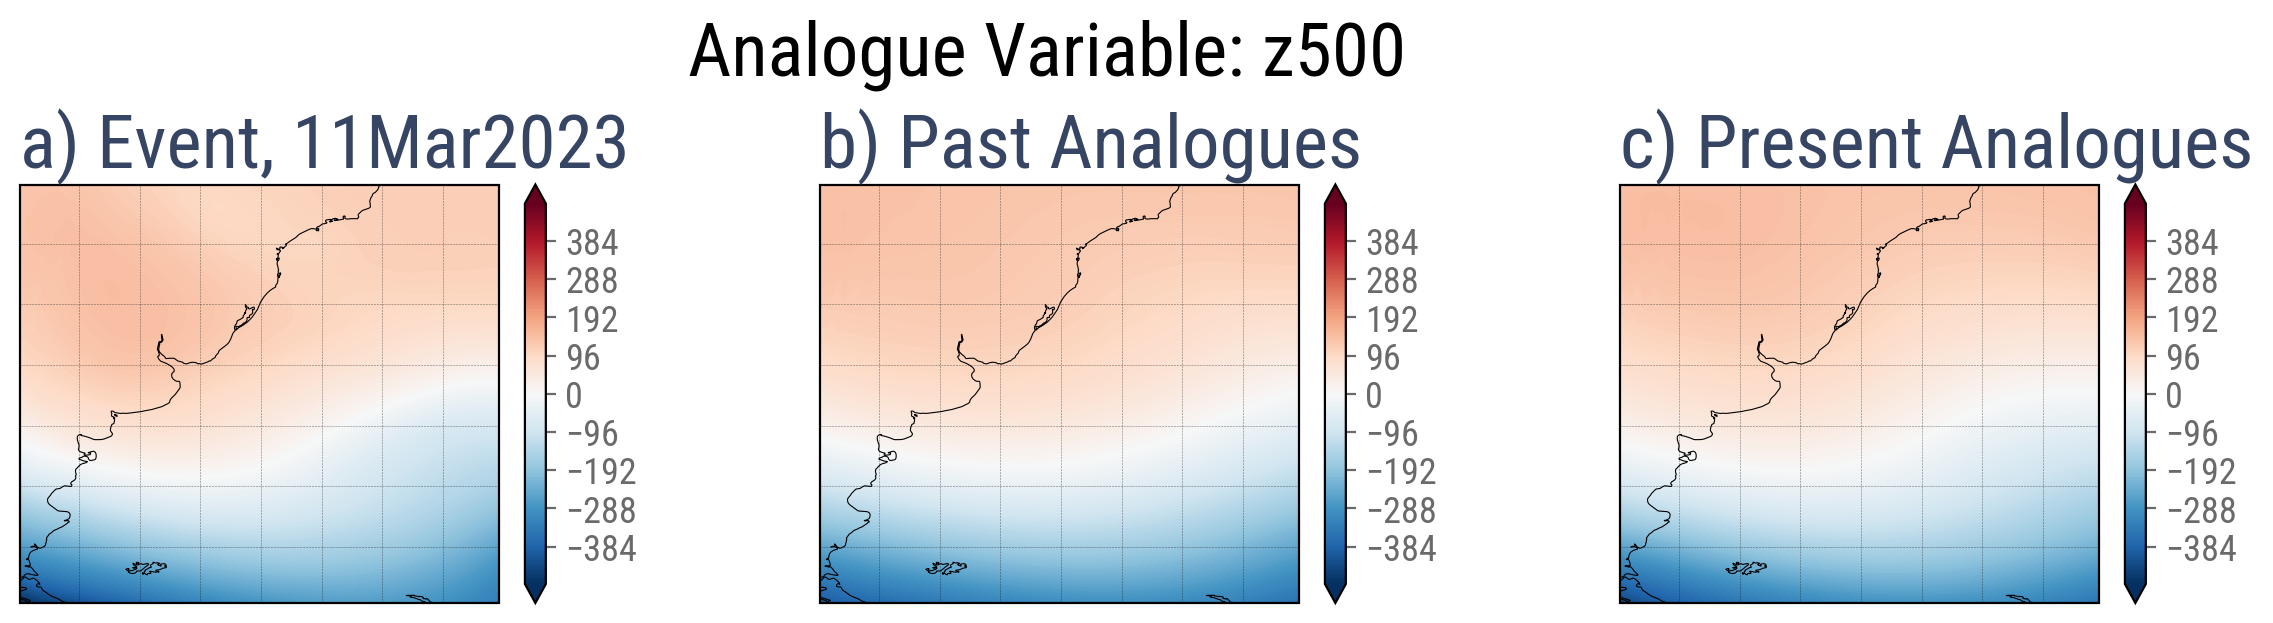

In [ ]:
# J: all the region extractions and data imports shoeld be removed from here as they have already been done

# Plot: Analogue variable

# EVENT FIELDS
E = E - E.collapsed(['latitude', 'longitude'], iris.analysis.MEAN)

# ANALOGUE COMPOSITES
PAST_comp = analogues_composite_anomaly_v2(daily_cube, dates_past)
PRST_comp = analogues_composite_anomaly_v2(daily_cube, dates_prst)

if ana_var == 'z500':
    PAST_comp = PAST_comp/10
    PRST_comp = PRST_comp/10
    E = E/10

fig = plt.figure(figsize=(12,3),layout='constrained',dpi=200)

lats=PRST_comp.coord('latitude').points
lons=PRST_comp.coord('longitude').points

x= np.round(np.arange(0, np.max([np.abs(PAST_comp.data), np.abs(PRST_comp.data), np.abs(E.data)]), 2))
con_lev=np.append(-x[::-1][:-1],x)

ax= plt.subplot(1,3,1,projection=ccrs.PlateCarree())
c1 = ax.contourf(lons, lats, E.data, levels=con_lev, cmap="RdBu_r", transform=ccrs.PlateCarree(), extend='both')
cbar = plt.colorbar(c1,fraction=0.046, pad=0.04)
cbar.ax.tick_params()
ax.set_title('a) Event, '+str(event_date_iris[2])+event_date_iris[1]+str(event_date_iris[0]), loc='left')
background(ax)

ax= plt.subplot(1,3,2,projection=ccrs.PlateCarree())
c1 = ax.contourf(lons, lats, PAST_comp.data, levels=con_lev, cmap="RdBu_r", transform=ccrs.PlateCarree(), extend='both')
cbar = plt.colorbar(c1,fraction=0.046, pad=0.04)
cbar.ax.tick_params()
ax.set_title('b) Past Analogues', loc='left')
background(ax)

ax= plt.subplot(1,3,3,projection=ccrs.PlateCarree())
c1 = ax.contourf(lons, lats, PRST_comp.data, levels=con_lev, cmap="RdBu_r", transform=ccrs.PlateCarree(), extend='both')
cbar = plt.colorbar(c1,fraction=0.046, pad=0.04)
cbar.ax.tick_params()
ax.set_title('c) Present Analogues', loc='left')
background(ax)

fig.suptitle('Analogue Variable: '+ ana_var)

In [94]:
# list of varaibles for plotting
if ana_var == 'z500':
    var_list = ['z500', 'msl', 'tp', 't2m']
elif ana_var == 'msl':
    var_list = ['msl', 'z500', 'tp', 't2m']

# J: again importing data we should already have, check which exactly so we can optimise this and maybe keep the full import as a backup if the region is changed

# sig fields, based on pointwise t-tests
sig_field = []
for each in var_list:
    sig_field.append(my.diff_significance(my.extract_region(my.reanalysis_data_v2(each, Y1, Y2, months), R2), dates_past, my.extract_region(my.reanalysis_data_v2(each, Y3, Y4, months), R2), dates_prst))

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/loading.py:713: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69


z500
Read file: era5_z500_daily.nc for date [2023, 'Mar', 11]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/sit

msl
Read file: era5_msl_daily.nc for date [2023, 'Mar', 11]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


tp
Read file: era5_tp_daily.nc for date [2023, 'Mar', 11]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/loading.py:713: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/loading.py:713: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You

t2m
Read file: era5_t2m_daily.nc for date [2023, 'Mar', 11]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


Text(0.0, 1.0, 'p) ')

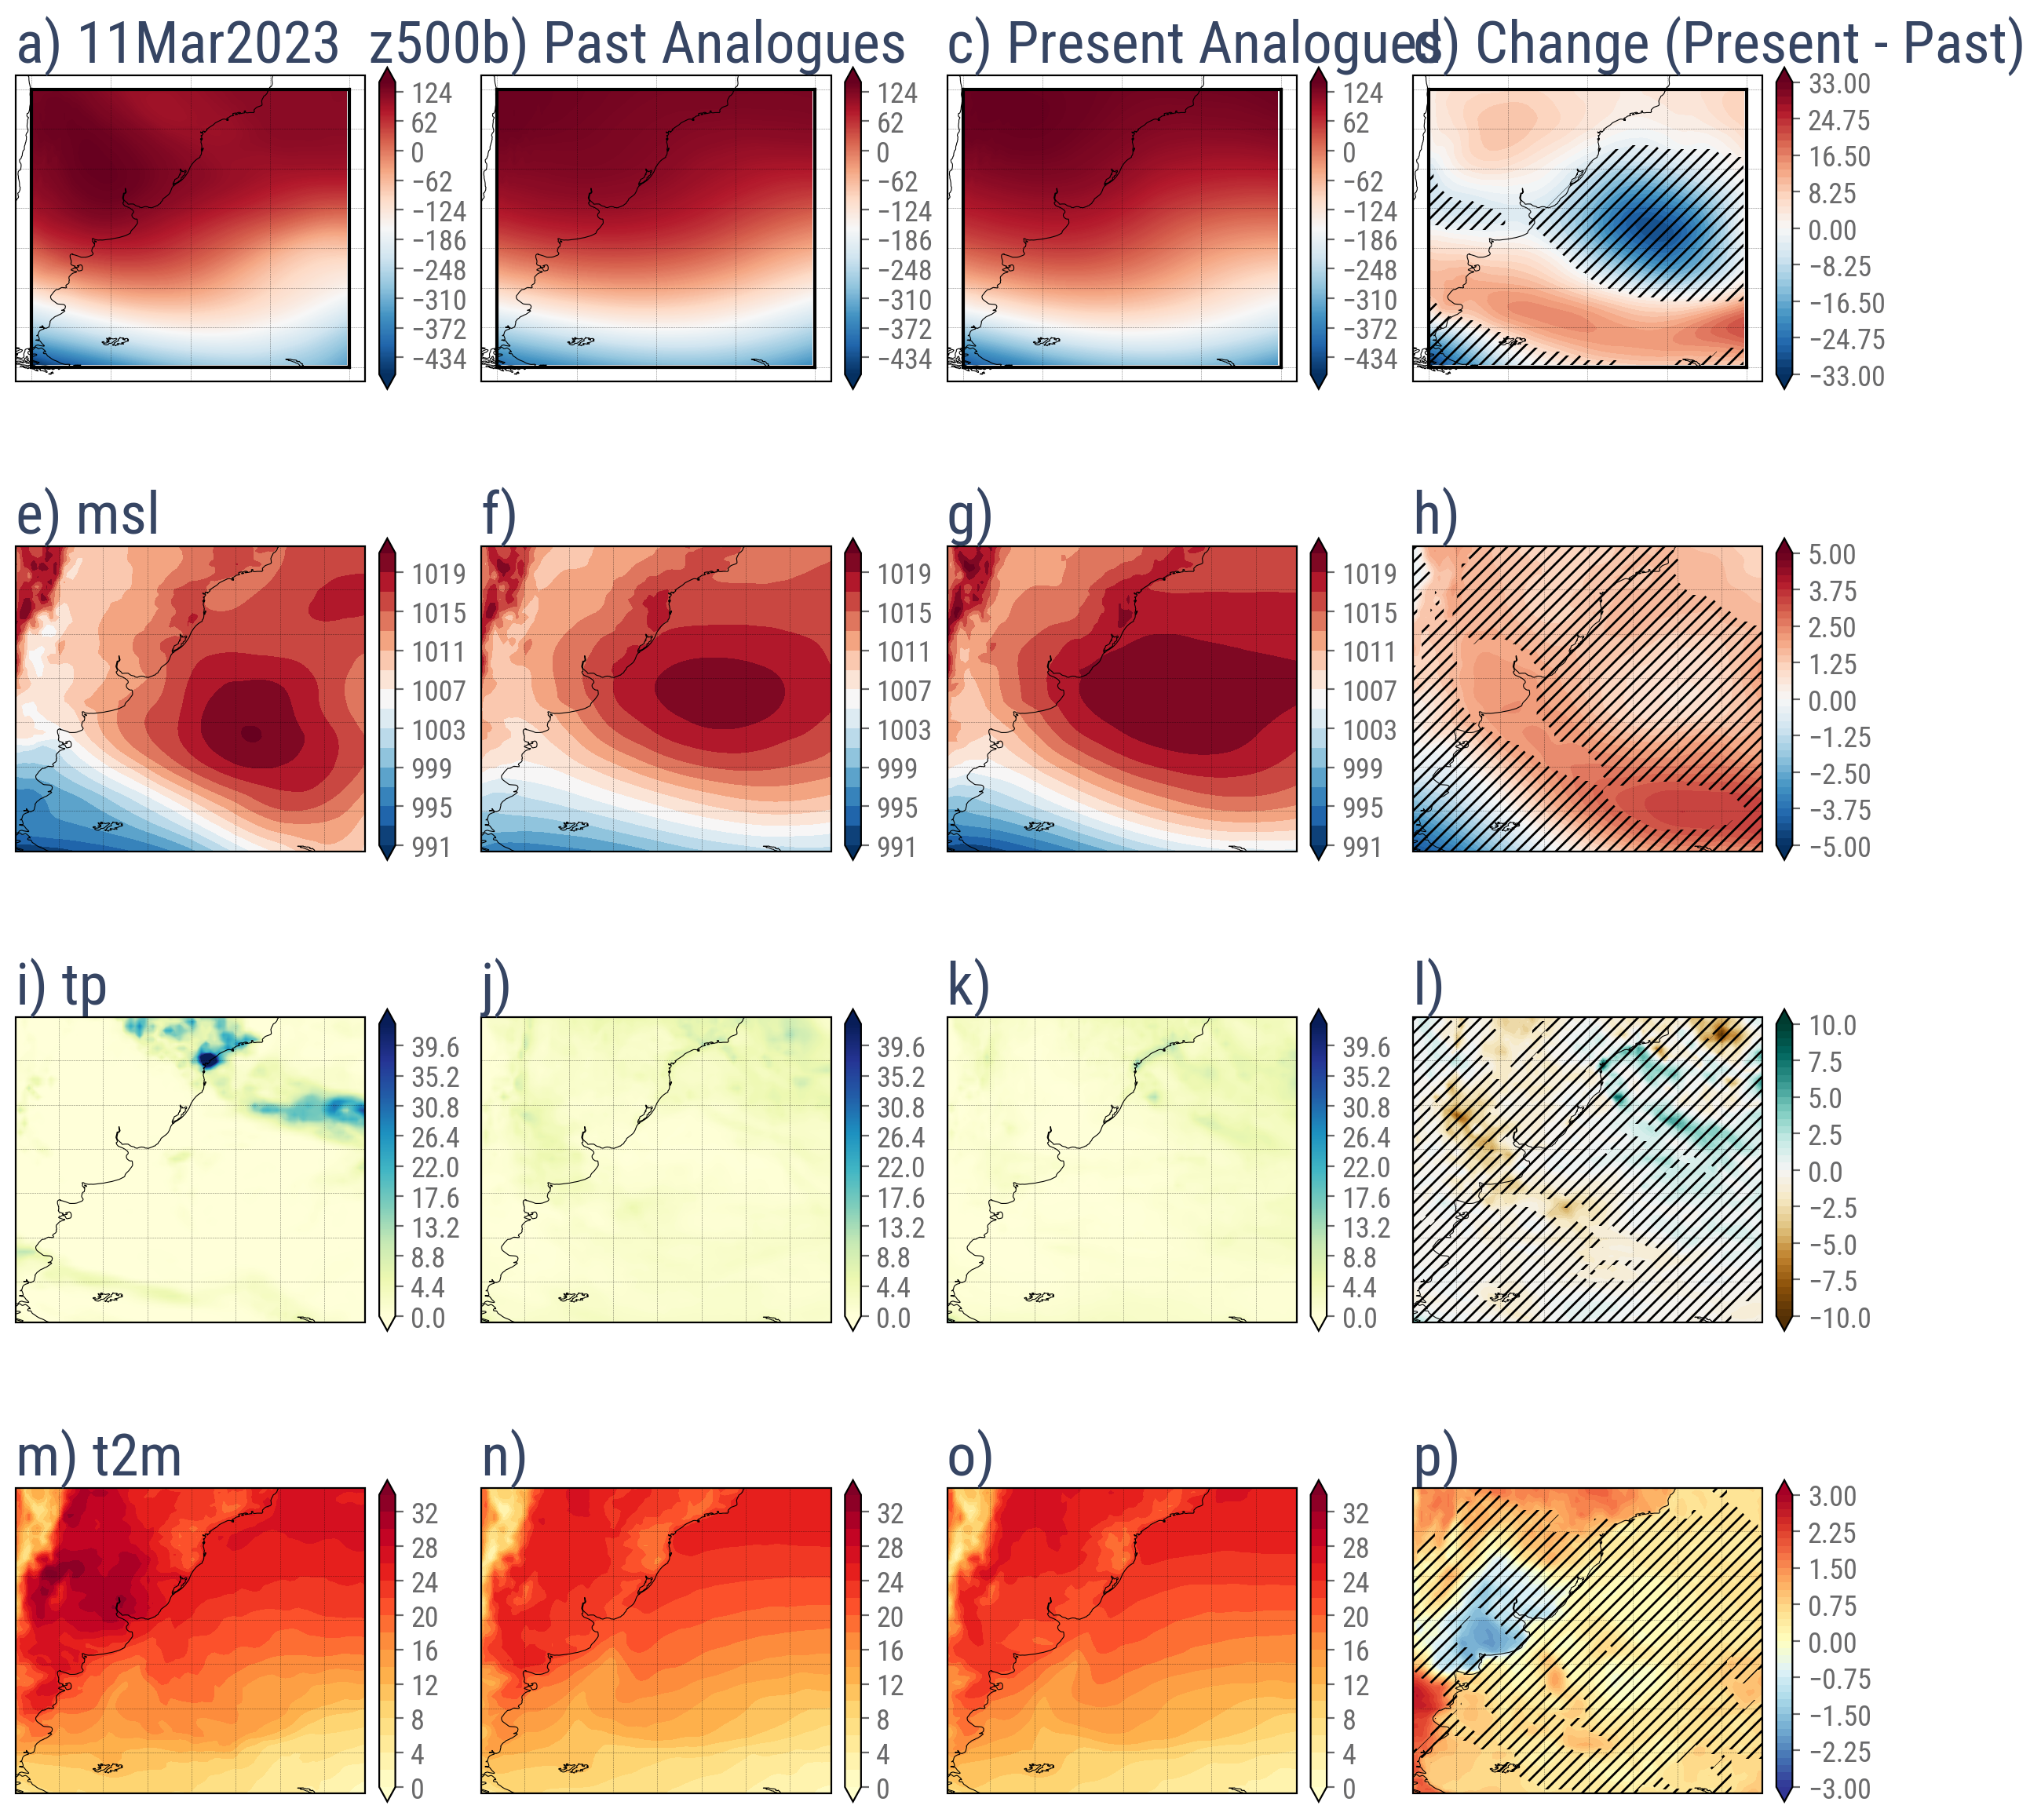

In [ ]:
# J: again redundant data imports and region extractions


# Plot: Z500, SLP, t2m, tp (ToDo: +winds when ERA5 not extended)
# Z500 plotted as anomalies (to remove the influence of the longterm trend)
fig = plt.figure(figsize=(12,12), layout='constrained', dpi=200)

for i, var in enumerate(var_list):
    print(var)
    if var == 'z500' or var == 'msl': CMAP = ["RdBu_r", "RdBu_r"]
    if var == 'tp': CMAP = ["YlGnBu", "BrBG"]
    if var == 't2m': CMAP = ["YlOrRd", "RdYlBu_r"]
    # EVENT FIELDS
    E = my.extract_region(my.reanalysis_data_single_date_v2(var, event_date_iris), R2)
    if var == ana_var:
        E = E - E.collapsed(['latitude', 'longitude'], iris.analysis.MEAN)
    # ANALOGUE COMPOSITES
    if var == ana_var:
        PRST_comp = analogues_composite_anomaly(dates_prst, var, R2)
        PAST_comp = analogues_composite_anomaly(dates_past, var, R2)
    else:
        PRST_comp = analogues_composite(dates_prst, var, R2)
        PAST_comp = analogues_composite(dates_past, var, R2)


    # Unit conversions
    # ============== Check this because the units should already be correct =============
    if var == 'z500':
        PAST_comp = PAST_comp * 0.0980665 # adjust for gravity?
        PRST_comp = PRST_comp * 0.0980665
        E = E * 0.0980665
    if var == 'msl':
        PAST_comp = PAST_comp * .01   
        PRST_comp = PRST_comp * .01
        E = E * .01    
    if var == 't2m':
        PAST_comp = PAST_comp - 273.15    # adjust kelvin to celsius
        PRST_comp = PRST_comp - 273.15
        E = E - 273.15   
    #======================================================================================
    
    lats=PRST_comp.coord('latitude').points
    lons=PRST_comp.coord('longitude').points 
    if var == 'z500' or var == 'msl':  
        con_lev = np.round(np.arange(np.min([PAST_comp.data, PRST_comp.data, E.data]), np.max([PAST_comp.data, PRST_comp.data, E.data]), 2))
        #con_lev = np.round(np.arange(-abs(max(([np.min([PAST_comp.data, PRST_comp.data, E.data]), np.max([PAST_comp.data, PRST_comp.data, E.data])]), key=abs)), abs(max(([np.min([PAST_comp.data, PRST_comp.data, E.data]), np.max([PAST_comp.data, PRST_comp.data, E.data])]), key=abs)), 2))
    if var == 't2m':
        con_lev = np.round(np.arange(0, np.max([PAST_comp.data, PRST_comp.data, E.data]), 2))
    if var == 'tp':
        con_lev = np.arange(0, np.max([PAST_comp.data,PRST_comp.data, E.data])/2, .2)
    # Plotting event
    ax= plt.subplot(len(var_list),4,(i*4)+1,projection=ccrs.PlateCarree())
    c1 = ax.contourf(lons, lats, E.data, levels=con_lev, cmap=CMAP[0], transform=ccrs.PlateCarree(), extend='both')
    cbar = plt.colorbar(c1,fraction=0.046, pad=0.04)
    cbar.ax.tick_params()
    ax.set_ylabel(var)
    background(ax)
    # Plotting Past Composite
    ax= plt.subplot(len(var_list),4,(i*4)+2,projection=ccrs.PlateCarree())
    c1 = ax.contourf(lons, lats, PAST_comp.data, levels=con_lev, cmap=CMAP[0], transform=ccrs.PlateCarree(), extend='both')
    cbar = plt.colorbar(c1,fraction=0.046, pad=0.04)
    cbar.ax.tick_params()
    background(ax)
    # Plotting Present Composite
    ax= plt.subplot(len(var_list),4,(i*4)+3,projection=ccrs.PlateCarree())
    c1 = ax.contourf(lons, lats, PRST_comp.data, levels=con_lev, cmap=CMAP[0], transform=ccrs.PlateCarree(), extend='both')
    cbar = plt.colorbar(c1,fraction=0.046, pad=0.04)
    cbar.ax.tick_params()
    background(ax)
    # Plotting Change
    ax= plt.subplot(len(var_list),4,(i*4)+4,projection=ccrs.PlateCarree())
    Dmax = np.round(np.nanmax(np.abs([np.nanmin((PRST_comp-PAST_comp).data), np.nanmax((PRST_comp-PAST_comp).data)])))
    diff_lev = np.linspace(-Dmax, Dmax, 41)
    c1 = ax.contourf(lons, lats, (PRST_comp-PAST_comp).data, levels=diff_lev, cmap=CMAP[1], transform=ccrs.PlateCarree(), extend='both')
    c2 = ax.contourf(lons, lats, sig_field[i].data, levels=[-2, 0, 2], hatches=['////', None], colors='none', transform=ccrs.PlateCarree())
    cbar = plt.colorbar(c1,fraction=0.046, pad=0.04)
    cbar.ax.tick_params()
    background(ax)
    #fig.suptitle('Analogue Variable: '+ana_var)

ax= plt.subplot(4,4,1,projection=ccrs.PlateCarree())    
ax.set_title('a) '+str(event_date_iris[2])+event_date_iris[1]+str(event_date_iris[0])+'  '+var_list[0], loc='left')
my.plot_box(ax, region)
ax= plt.subplot(4,4,2,projection=ccrs.PlateCarree())  
ax.set_title('b) Past Analogues', loc='left')
my.plot_box(ax, region)
ax= plt.subplot(4,4,3,projection=ccrs.PlateCarree())  
ax.set_title('c) Present Analogues', loc='left')
my.plot_box(ax, region)
ax= plt.subplot(4,4,4,projection=ccrs.PlateCarree())  
ax.set_title('d) Change (Present - Past)', loc='left')
my.plot_box(ax, region)


plt.subplot(4,4,5,projection=ccrs.PlateCarree()) .set_title('e) '+var_list[1], loc='left')
plt.subplot(4,4,6,projection=ccrs.PlateCarree()) .set_title('f) ', loc='left')
plt.subplot(4,4,7,projection=ccrs.PlateCarree()) .set_title('g) ', loc='left')
plt.subplot(4,4,8,projection=ccrs.PlateCarree()) .set_title('h) ', loc='left')

plt.subplot(4,4,9,projection=ccrs.PlateCarree()) .set_title('i) '+var_list[2], loc='left')
plt.subplot(4,4,10,projection=ccrs.PlateCarree()) .set_title('j) ', loc='left')
plt.subplot(4,4,11,projection=ccrs.PlateCarree()) .set_title('k) ', loc='left')
plt.subplot(4,4,12,projection=ccrs.PlateCarree()) .set_title('l) ', loc='left')

plt.subplot(4,4,13,projection=ccrs.PlateCarree()) .set_title('m) '+var_list[3], loc='left')
plt.subplot(4,4,14,projection=ccrs.PlateCarree()) .set_title('n) ', loc='left')
plt.subplot(4,4,15,projection=ccrs.PlateCarree()) .set_title('o) ', loc='left')
plt.subplot(4,4,16,projection=ccrs.PlateCarree()) .set_title('p) ', loc='left')

In [ ]:
# Summary print out
print('Summary: identify analogues domain')
print('Event definition:')
print('     Date: ', event_date_iris)
print('Analogue calculation:')
print('     Months assessed: ', months)
print('     Number of analogues: ', N)
print('     Analogue domain: ', region)
print('     Circulation variable: ', ana_var)
print('Timeslices:')
print('      Past: ',Y1,'-',Y2)
print('      Present: ',Y3,'-',Y4)
print('Plotted domain: ', R2)

Summary: identify analogues domain
Event definition:
     Date:  [2023, 'Mar', 11]
Analogue calculation:
     Months assessed:  ['Feb', 'Mar', 'Apr']
     Number of analogues:  27
     Analogue domain:  [-20, -55, -30, -70]
     Circulation variable:  z500
Timeslices:
      Past:  1950 - 1980
      Present:  1994 - 2024
Plotted domain:  [-20, -55, -30, -70]


## 3.12 Assess change in frequency:
- a. Action: run script C3S04_analogues_Frequency.ipynb
    - i. Requires input of initial variables (date, analogue domain, circulation variable)
    - ii. Software produces figure of change in frequency of similar circulation analogues (Fig.2; See Figures description section)
- b. Software calculates Euclidean distance to all events and identifies value of closest analogues within all data for 5%, 10% and 20% thresholds.
- c. Software produces figure of frequencies of closest analogues of 5%, 10%, 20%, including 10- year rolling mean, linear trend and p-values
- d. Copy this Figure to the scientific report to become the second analogues figure
- e. Note the final text output, providing guidance for the report
    - i. Increasing / No trend / Decreasing
    - ii. Significant / Not significant
- f. Edit report text to detail the conclusions (see Report template):

In [104]:
# J: these variables are already defined above, can be removed from here
# Defining the variables:
# date = [2025, 'Apr', 5]         # as in 3.8A 
# R1 = [50, 25, -70, -110] 
# ana_var = 'z500' # 'msl' or 'z500'

# start and end of period assessed
Y1 = 1950 # timeslice 1 start year
Y2 = 2024 # timeslice 1 end year

N = my.number_of_analogues(Y1, Y2, months)

In [105]:
# J: only use code after 'Find event data' comment. Check the function to see if there is unecessary data imports or region extractions

event_data = 'era5'

# Find event data
event_msl, event_tp, event_t2m, event_wind = my.event_data_era_v2(event_data, event_date_iris, ana_var)

P1_msl = my.reanalysis_data_v2(ana_var, Y1, Y2, months)

Read file: era5_z500_daily.nc for date [2023, 'Mar', 11]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/loading.py:713: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)


Read file: era5_tp_daily.nc for date [2023, 'Mar', 11]
Read file: era5_t2m_daily.nc for date [2023, 'Mar', 11]
Read file: era5_sfcWind_daily.nc for date [2023, 'Mar', 11]


In [ ]:
# Find euclidean distance to all events
E = my.extract_region(event_msl, region)
E = E - E.collapsed(['latitude', 'longitude'], iris.analysis.MEAN)
P = my.extract_region(P1_msl, region)
P = P - P.collapsed(['latitude', 'longitude'], iris.analysis.MEAN)
#D = []
#for Y in np.arange(Y1, Y2):
#    D.append(my.euclidean_distance(P.extract(iris.Constraint(year = Y)), E)[:90])
#ED_max = np.max(D)
#S = 1- D/ED_max # similarity measure, 0 to 1.

D = []
for Y in np.arange(Y1, Y2):
    D.append(my.euclidean_distance(P.extract(iris.Constraint(year = Y)), E))
x = []
for v in np.arange(len(D)):
    x.append(np.max(D[v]))
ED_max = np.max(x)
S = []
for v in np.arange(len(D)):
    S.append(1-D[v]/np.max(D[v]))
    
# Thresholds - identify value of different percentiles within all data
Sout = np.concatenate(S).ravel()
per5 = np.percentile(Sout,95) # upper 5%
per10 = np.percentile(Sout,90) # upper 10%
per20 = np.percentile(Sout,80) # upper 20%

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial c

In [107]:
# Thresholds - count for each year
yr5 = []; yr10 = []; yr20 = []
for each in np.arange(len(S)):
    j = S[each][:]
    yr5.append(sum(i > per5 for i in j))
    yr10.append(sum(i > per10 for i in j))
    yr20.append(sum(i > per20 for i in j))

roll5 = []; roll10 = []; roll20 = []
for i in np.arange(len(yr5)-10):
    roll5.append(np.mean(yr5[i:i+10]))
    roll10.append(np.mean(yr10[i:i+10]))
    roll20.append(np.mean(yr20[i:i+10]))

In [108]:
print(len(yr10))
print(Y1, Y2)
print(len(np.arange(Y1, Y2)))

74
1950 2024
74


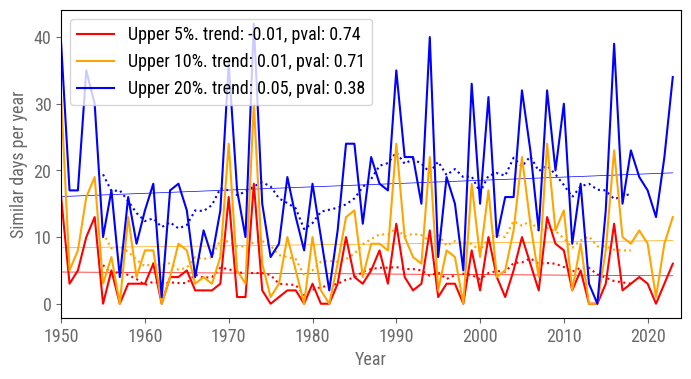

In [109]:
# Plot timeseries with linear trends and 10-yr rolling means
fig, ax = plt.subplots(1,1,figsize = (8, 4))

# linear trends
trend = np.polyfit(np.arange(Y1, Y2), yr10,1)
trendpoly = np.poly1d(trend) 
slope10, intercept, r_value, pval_10, std_err = stats.linregress(np.arange(Y1, Y2), yr10)
ax.plot(np.arange(Y1, Y2), trendpoly(np.arange(Y1, Y2)), color='orange', linewidth=.5)
text10 = 'Upper 10%. trend: '+"%.2f" % round(slope10, 2)+', pval: '+"%.2f" % round(pval_10, 2)

trend = np.polyfit(np.arange(Y1, Y2), yr5,1)
trendpoly = np.poly1d(trend) 
slope5, intercept, r_value, pval_5, std_err = stats.linregress(np.arange(Y1, Y2), yr5)
ax.plot(np.arange(Y1, Y2), trendpoly(np.arange(Y1, Y2)), color='r', linewidth=.5)
text5 = 'Upper 5%. trend: '+"%.2f" % round(slope5, 2)+', pval: '+"%.2f" % round(pval_5, 2)

trend = np.polyfit(np.arange(Y1, Y2), yr20,1)
trendpoly = np.poly1d(trend) 
slope20, intercept, r_value, pval_20, std_err = stats.linregress(np.arange(Y1, Y2), yr20)
ax.plot(np.arange(Y1, Y2), trendpoly(np.arange(Y1, Y2)), color='b', linewidth=.5)
text20 = 'Upper 20%. trend: '+"%.2f" % round(slope20, 2)+', pval: '+"%.2f" % round(pval_20, 2)

ax.plot(np.arange(Y1+5, Y2-5), roll5, 'r:')
ax.plot(np.arange(Y1+5, Y2-5), roll10, color='orange', linestyle=':')
ax.plot(np.arange(Y1+5, Y2-5), roll20, 'b:')

ax.plot(np.arange(Y1, Y2), yr5,'r', label=text5)
ax.plot(np.arange(Y1, Y2), yr10,color='orange', label=text10)
ax.plot(np.arange(Y1, Y2), yr20,'b', label=text20)

ax.set_xlabel('Year')
ax.set_ylabel("Similar days per year")

ax.set_xlim([Y1, Y2])
ax.legend(loc=2)

In [ ]:
# Summary print out
print('Summary: Change in frequency of similar circulation days')
print('Event definition:')
print('     Date: ', event_date_iris)
print('Analogue calculation:')
print('     Months assessed: ', months)
print('     Number of analogues: ', N)
print('     Analogue domain: ', region)
print('     Circulation variable: ', ana_var)
print('Timeframe:')
print('      Past: ',Y1,'-',Y2)

print('Results:')
text20='Upper 5%. trend: '+"%.2f" % round(slope5, 2)+', pval: '+"%.2f" % round(pval_5, 2)
print(text20)
text20='Upper 10%. trend: '+"%.2f" % round(slope10, 2)+', pval: '+"%.2f" % round(pval_10, 2)
print(text20)
text20='Upper 20%. trend: '+"%.2f" % round(slope20, 2)+', pval: '+"%.2f" % round(pval_20, 2)
print(text20)

print('Conclusions:')
if slope5>0 and slope10>0 and slope20>0:
    print('1. Increasing')
elif slope5<0 and slope10<0 and slope20<0:
    print('1. Decreasing')
else:
    print('1. No trend')

n=0
for i in [pval_5, pval_10, pval_20]:
    if i < 0.05:
        n+=1
if n>1:
    print('2. Significant')
else:
    print('2. Not significant')

Summary: Change in frequency of similar circulation days
Event definition:
     Date:  [2023, 'Mar', 11]
Analogue calculation:
     Months assessed:  ['Feb', 'Mar', 'Apr']
     Number of analogues:  66
     Analogue domain:  [-20, -55, -30, -70]
     Circulation variable:  z500
Timeframe:
      Past:  1950 - 2024
Results:
Upper 5%. trend: -0.01, pval: 0.74
Upper 10%. trend: 0.01, pval: 0.71
Upper 20%. trend: 0.05, pval: 0.38
Conclusions:
1. No trend
2. Not significant


## 3.13 For precipitation cases only, assess postage stamp figures:
- a. Note that science is still under development, check later whether any changes need to be made.
- b. If the event is a rainfall extreme the analogues are unlikely to show similar rainfall fields to the observed event. This is because the large-scale circulation alone is not a good predictor of rainfall, other drivers are also important. For rainfall events an additional figure should be produced to show the spread in rainfall patterns in the analogues. <font color="yellow"> What do they expect here? Is there an example? </font>
- c. Action: run script C3S05_analogues_postagestamps.ipynb
    - i. Requires input of initial variables (date, analogue domain, circulation variable)
    - ii. For plotting purposes use analogues number of N=19
- d. Software calculates the analogue dates for each period.
- e. Software plots precipitation on the dates of the 19 past and 19 present analogues (plus theevent) that are closest to the event circulation
- f. Action: Check whether the majority of the analogues show rainfall over the event region,which suggests we can use analogues in this rainfall events to conclude on changes inrainfall.
    - i. If the majority (at least in the present day climate) shows rainfall in the same region ason the event day, we can use the conclusions on precipitation changes
    - ii. If at least half of the analogues show rainfall close to the same region as on the eventday, we can use the conclusion on precipitation changes, but have less confidence inconclusions
    - iii. If the majority shows different or no rainfall we can conclude that the analoguesanalysis is not useful to describe rainfall in this case. We can conclude that rainfallpatterns are not always the same, but conclusions about circulation changes are valid.
- g. Action: copy the two output figures (past and present analogues) into the report to become the third analogues figure and describe conclusion.

yellow highlighted steps needed?

In [111]:
# Defining the variables:
# ana_var = 'z500' # already defined earlier 'msl' or 'z500'
haz_var = 'tp'

#redefining the time slices
# start and end of timeslices. Both timeslices should be same length for fair comparison
Y1 = 1950 # timeslice 1 start year
Y2 = 1980 # timeslice 1 end year
Y3 = 1994 # timeslice 2 start year
Y4 = 2024 # timeslice 2 end year

# number of analogues to use - set at 1% (assuming 30 day months) of timeslice 1 days 
N = my.number_of_analogues(Y1, Y2, months)
# Or use this line to manually select N, for plotting a multiple of 5, minus 1, ensures tidy figure
N = 19

In [ ]:
# select data for the time slices
past_daily_cube = my.reanalysis_data_v2(ana_var, Y1, Y2, months)
past_daily_cube_reg = my.extract_region(past_daily_cube, region)

present_daily_cube = my.reanalysis_data_v2(ana_var, Y3, Y4, months)
present_daily_cube_reg = my.extract_region(present_daily_cube, region)

# select
event_cube = z500_event_cube
event_domain = z500_domain_iris
daily_cube = z500_daily_cube_reg

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [ ]:
# J: edited to use custom function edit parameters

dates_past = anomaly_period_outputs_v2(past_daily_cube_reg, event_cube, event_date_iris, N)
dates_prst = anomaly_period_outputs_v2(present_daily_cube_reg, event_cube, event_date_iris, N)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial c

In [ ]:
# J: look at how to change the data import and region extraction to use already imported data

# Past date fields
circ_past = iris.cube.CubeList([])
haz_past = iris.cube.CubeList([])

n = len(dates_past)
for each in range(n):
    year = int(dates_past[each][:4])
    month = calendar.month_abbr[int(dates_past[each][4:-2])]
    day = int(dates_past[each][-2:])
    circ_past.append(my.extract_region(my.reanalysis_data_single_date_v2(ana_var, [year, month, day]), region))
    haz_past.append(my.extract_region(my.reanalysis_data_single_date_v2(haz_var, [year, month, day]), region))

Read file: era5_z500_daily.nc for date [1952, 'Mar', 2]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/loading.py:713: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)


Read file: era5_tp_daily.nc for date [1952, 'Mar', 2]
Read file: era5_z500_daily.nc for date [1953, 'Mar', 8]
Read file: era5_tp_daily.nc for date [1953, 'Mar', 8]
Read file: era5_z500_daily.nc for date [1963, 'Feb', 1]
Read file: era5_tp_daily.nc for date [1963, 'Feb', 1]
Read file: era5_z500_daily.nc for date [1954, 'Feb', 11]
Read file: era5_tp_daily.nc for date [1954, 'Feb', 11]
Read file: era5_z500_daily.nc for date [1959, 'Feb', 27]
Read file: era5_tp_daily.nc for date [1959, 'Feb', 27]
Read file: era5_z500_daily.nc for date [1950, 'Feb', 6]
Read file: era5_tp_daily.nc for date [1950, 'Feb', 6]
Read file: era5_z500_daily.nc for date [1950, 'Mar', 11]
Read file: era5_tp_daily.nc for date [1950, 'Mar', 11]
Read file: era5_z500_daily.nc for date [1963, 'Feb', 22]
Read file: era5_tp_daily.nc for date [1963, 'Feb', 22]
Read file: era5_z500_daily.nc for date [1961, 'Mar', 28]
Read file: era5_tp_daily.nc for date [1961, 'Mar', 28]
Read file: era5_z500_daily.nc for date [1968, 'Feb', 17]

In [121]:
# color map
colors = [
    (1.0, 1.0, 1.0),       # <0 white
    (0.8, 0.8, 0.8),       # 1-10 light grey
    (0.7, 1.0, 0.7),       # 11-20 light green
    (0.0, 0.6, 0.0),       # 21-30 green
    (0.6, 0.8, 1.0),       # 31-40 light blue
    (0.55, 0.55, 1.0),     # 41-50 periwinkle
    (1.0, 0.6, 0.8),       # 51-60 pink
    (0.6, 0.2, 0.8),       # 61-70 purple
    (1.0, 0.2, 0.2),       # 71-80 red
    (0.6, 0.0, 0.0),       # >80 dark red
]

# Create colormap
my_cmap = ListedColormap(colors, name="custom_geert")

levelsGL = [-999, 0, 10, 20, 30, 40, 50, 60, 70, 80, 999]

norm = BoundaryNorm(levelsGL, ncolors=len(colors))

Read file: era5_z500_daily.nc for date [2023, 'Mar', 11]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/loading.py:713: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)


Read file: era5_tp_daily.nc for date [2023, 'Mar', 11]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packag

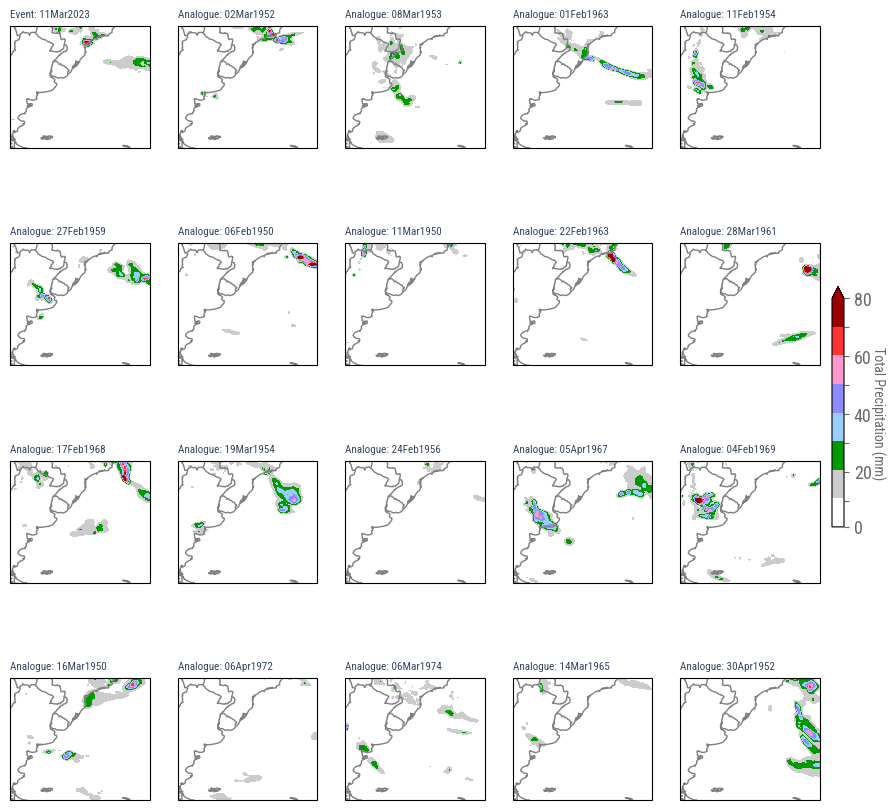

In [ ]:
# J: look at data imports and region extractions
# J: Look at what variables are repeated

## OPTIONS ##
# How many analogues?
n = 19 # no more than 29
# With circulation?
circ_plot = 0 # 1: plots circulation contours, 0: does not

import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# cpt = pd.read_csv('/usr/people/thompson/WP1/wetVdry/paper_figs/colormapGeert.txt',sep=' ',index_col=False) #.to_xarray()
# colorsGL = [(cpt['R1'][i]/255,cpt['G1'][i]/255,cpt['B1'][i]/255) for i,v in enumerate(cpt['R1'])]
# levelsGL = cpt['val1'].astype('int')
# cmap_name = 'my_list'
# my_cmap = LinearSegmentedColormap.from_list(cmap_name, colorsGL, N=24)

# replacement for color map we are missing
# my_cmap = plt.cm.get_cmap("RdBu_r", 24)
levelsGL = list(range(-12, 12))

# Past dates plot
lats=circ_past[0].coord('latitude').points
lons=circ_past[0].coord('longitude').points
fig, axs = plt.subplots(nrows=(int(np.ceil((n+1)/5))), ncols=5, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,12))

circ = my.extract_region(my.reanalysis_data_single_date_v2(ana_var, event_date_iris), region)
haz = my.extract_region(my.reanalysis_data_single_date_v2(haz_var, event_date_iris), region)

if haz_var == 'tp':
    c = axs[0,0].contourf(lons, lats, haz.data, levels=np.linspace(1, 80, 9), cmap = my_cmap, transform=ccrs.PlateCarree(), extend='max')
    fig.subplots_adjust(right=0.8, hspace=-.2)
    cbar_ax = fig.add_axes([0.81, 0.4, 0.01, 0.2])
    fig.colorbar(c, cax=cbar_ax, ticks=np.arange(0, 100, 10))
    cbar_ax.set_ylabel('Total Precipitation (mm)', labelpad=10, rotation=270, fontsize=10)
    cbar_ax.set_yticklabels(['0', '', '20','','40','','60','','80',''])
elif haz_var == 't2m':
    c = axs[0,0].contourf(lons, lats, haz.data-273.15, levels=np.linspace(np.min(haz.data-273.15), np.max(haz.data-273.15), 9), cmap = plt.cm.get_cmap('RdBu_r'), transform=ccrs.PlateCarree(), extend='max')
    

if circ_plot == 1: c2 = axs[0,0].contour(lons, lats, circ.data/100, colors='k', transform=ccrs.PlateCarree(), extend='both')
axs[0,0].clabel(c2, inline=1, fontsize=12)
axs[0,0].add_feature(cf.BORDERS, color='grey')
axs[0,0].add_feature(cf.COASTLINE, color='grey')
axs[0,0].set_title('Event: '+str(event_date_iris[2])+event_date_iris[1]+str(event_date_iris[0]), loc='left', fontsize=8)


for i, ax in enumerate(np.ravel(axs)[1:n+1]):
    if haz_var == 'tp':
        c = ax.contourf(lons, lats, haz_past[i].data, levels=np.linspace(1, 80, 9), cmap = my_cmap, transform=ccrs.PlateCarree(), extend='max')
    elif haz_var == 't2m':
        c = ax.contourf(lons, lats, haz_past[i].data-273.15, levels=np.linspace(np.min(haz_past[i].data-273.15), np.max(haz_past[i].data-273.15), 9), cmap = plt.cm.get_cmap('RdBu_r'), transform=ccrs.PlateCarree(), extend='max')
    if circ_plot == 1: c2 = ax.contour(lons, lats, circ_past[i].data/100, colors='k', transform=ccrs.PlateCarree(), extend='both')
    ax.clabel(c2, inline=1, fontsize=12)
    ax.add_feature(cf.BORDERS, color='grey')
    ax.add_feature(cf.COASTLINE, color='grey')
    ax.set_title('Analogue: '+str(dates_past[i][-2:])+calendar.month_abbr[int(dates_past[i][4:-2])]+str(dates_past[i][:4]), loc='left', fontsize=8)

In [ ]:
# Look at data imports and region extractions

# Prst date fields
circ_prst = iris.cube.CubeList([])
haz_prst = iris.cube.CubeList([])

n = len(dates_prst)
for each in range(n):
    year = int(dates_prst[each][:4])
    month = calendar.month_abbr[int(dates_prst[each][4:-2])]
    day = int(dates_prst[each][-2:])
    circ_prst.append(my.extract_region(my.reanalysis_data_single_date_v2(ana_var, [year, month, day]), region))
    haz_prst.append(my.extract_region(my.reanalysis_data_single_date_v2(haz_var, [year, month, day]), region))

Read file: era5_z500_daily.nc for date [2012, 'Mar', 17]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/loading.py:713: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)


Read file: era5_tp_daily.nc for date [2012, 'Mar', 17]
Read file: era5_z500_daily.nc for date [2020, 'Apr', 18]
Read file: era5_tp_daily.nc for date [2020, 'Apr', 18]
Read file: era5_z500_daily.nc for date [1997, 'Feb', 7]
Read file: era5_tp_daily.nc for date [1997, 'Feb', 7]
Read file: era5_z500_daily.nc for date [1997, 'Apr', 8]
Read file: era5_tp_daily.nc for date [1997, 'Apr', 8]
Read file: era5_z500_daily.nc for date [2002, 'Apr', 4]
Read file: era5_tp_daily.nc for date [2002, 'Apr', 4]
Read file: era5_z500_daily.nc for date [2018, 'Feb', 14]
Read file: era5_tp_daily.nc for date [2018, 'Feb', 14]
Read file: era5_z500_daily.nc for date [2010, 'Mar', 25]
Read file: era5_tp_daily.nc for date [2010, 'Mar', 25]
Read file: era5_z500_daily.nc for date [2001, 'Mar', 14]
Read file: era5_tp_daily.nc for date [2001, 'Mar', 14]
Read file: era5_z500_daily.nc for date [2016, 'Mar', 16]
Read file: era5_tp_daily.nc for date [2016, 'Mar', 16]
Read file: era5_z500_daily.nc for date [2015, 'Mar', 16

Read file: era5_z500_daily.nc for date [2023, 'Mar', 11]
Read file: era5_tp_daily.nc for date [2023, 'Mar', 11]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packag

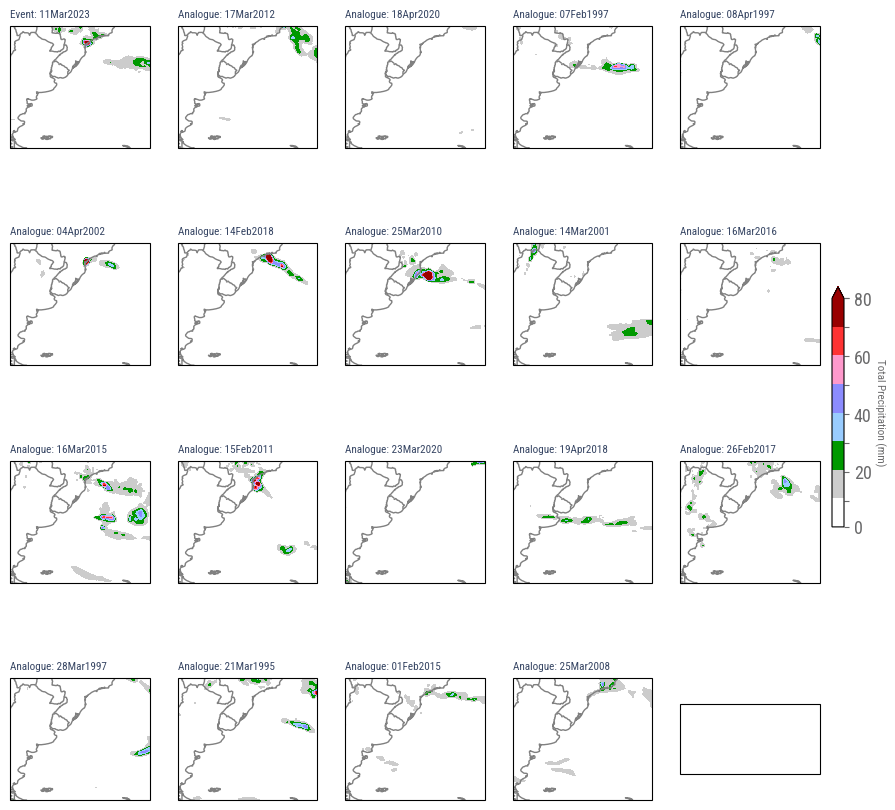

In [ ]:
# J: look at data imports and region extractions

# Past dates plot
lats=circ_prst[0].coord('latitude').points
lons=circ_prst[0].coord('longitude').points
fig, axs = plt.subplots(nrows=(int(np.ceil((n+1)/5))), ncols=5, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,12))

circ = my.extract_region(my.reanalysis_data_single_date_v2(ana_var, event_date_iris), region)
haz = my.extract_region(my.reanalysis_data_single_date_v2(haz_var, event_date_iris), region)

### J: Why are they using Kelvin?

if haz_var == 'tp':
    c = axs[0,0].contourf(lons, lats, haz.data, levels=np.linspace(1, 80, 9), cmap = my_cmap, transform=ccrs.PlateCarree(), extend='max')
    fig.subplots_adjust(right=0.8, hspace=-0.2)
    cbar_ax = fig.add_axes([0.81, 0.4, 0.01, 0.2])
    fig.colorbar(c, cax=cbar_ax, ticks=np.arange(0, 100, 10))
    cbar_ax.set_ylabel('Total Precipitation (mm)', labelpad=10, rotation=270, fontsize=8)
    cbar_ax.set_yticklabels(['0', '', '20','','40','','60','','80',''])
elif haz_var == 't2m':
    c = axs[0,0].contourf(lons, lats, haz.data-273.15, levels=np.linspace(np.min(haz.data-273.15), np.max(haz.data-273.15), 9), cmap = plt.cm.get_cmap('RdBu_r'), transform=ccrs.PlateCarree(), extend='max')
    

if circ_plot == 1: c2 = axs[0,0].contour(lons, lats, circ.data/100, colors='k', transform=ccrs.PlateCarree(), extend='both')
axs[0,0].clabel(c2, inline=1, fontsize=12)
axs[0,0].add_feature(cf.BORDERS, color='grey')
axs[0,0].add_feature(cf.COASTLINE, color='grey')
axs[0,0].set_title('Event: '+str(event_date_iris[2])+event_date_iris[1]+str(event_date_iris[0]), loc='left', fontsize=8)


for i, ax in enumerate(np.ravel(axs)[1:n+1]):
    if haz_var == 'tp':
        c = ax.contourf(lons, lats, haz_prst[i].data, levels=np.linspace(1, 80, 9), cmap = my_cmap, transform=ccrs.PlateCarree(), extend='max')
    elif haz_var == 't2m':
        c = ax.contourf(lons, lats, haz_prst[i].data-273.15, levels=np.linspace(np.min(haz_prst[i].data-273.15), np.max(haz_prst[i].data-273.15), 9), cmap = plt.cm.get_cmap('RdBu_r'), transform=ccrs.PlateCarree(), extend='max')
    if circ_plot == 1: c2 = ax.contour(lons, lats, circ_prst[i].data/100, colors='k', transform=ccrs.PlateCarree(), extend='both')
    ax.clabel(c2, inline=1, fontsize=12)
    ax.add_feature(cf.BORDERS, color='grey')
    ax.add_feature(cf.COASTLINE, color='grey')
    ax.set_title('Analogue: '+str(dates_prst[i][-2:])+calendar.month_abbr[int(dates_prst[i][4:-2])]+str(dates_prst[i][:4]), loc='left', fontsize=8)

# <font color="red">Continue Here --> We are missing the last plot of this last cell</font>